In [2]:
import torch
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, precision_recall_curve, auc, confusion_matrix, accuracy_score
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import sys
ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(ROOT))
from src.utils import seed_everything, load_manifest, get_data_paths
from finetuning import run_finetuning_pipeline
from train_probe import paired_bootstrap_auc

### 1. Setup


We set up the seed and check whether cuda is available.

In [3]:
seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

[Seed] Global seed set to 42
Using device: cuda


Global set up for filepaths through manifest.


Setup up all supplementary files and data

In [4]:
EPOCHS = 10 # How many times does it see the data
LR = 1e-4 # Learning Rate


manifest_path = ROOT / "data" / "manifest.json"
manifest = load_manifest(manifest_path)
path_dict = get_data_paths(manifest, ROOT)

filelist = pd.read_csv(path_dict["filelist_csv"])
filelist["Split"] = filelist["Split"].astype(str).str.lower().str.strip()
filelist["label_hfref"] = (filelist["EF"] <= 40).astype("int8")
videos_root = path_dict["videos_root"]

# What tasks are we running? By default it is set to both models at once
# (Because I want to shower while I wait)
tasks = [
        {"model_type": "r2plus1d", "batch_size": 8, "tune_blocks": 1},
        {"model_type": "mvit",     "batch_size": 4, "tune_blocks": 2}
    ]

In [5]:
# How many patients actually have REF?
print(filelist[filelist["label_hfref"] == 1].sum())

# 1264 out of 10030, roughly one-eighth.

FileName          0X10094BA0A028EAC30X100E3B8D3280BEC50X100E491B...
EF                                                     36784.549447
ESV                                                   133752.550389
EDV                                                   184355.639256
FrameHeight                                                  141568
FrameWidth                                                   141568
FPS                                                           63571
NumberOfFrames                                               209274
Split             valtraintraintraintrainvalvaltraintrainvaltrai...
label_hfref                                                    1264
dtype: object


### 2. Main Loop.
This is the heaviest part of the notebook. Use the code block below to actually fine tune and evaluate the models and save the results to a file.

Basically:
- Sets up a loop for however many models are set up
- For each model, does fine-tuning and checks accuracy on validation data.

In [ ]:
# Main loop
results_summary = {}
    
for task in tasks:
    t_auc, t_f1 = run_finetuning_pipeline(
        model_type=task["model_type"],
        batch_size=task["batch_size"],
        tune_blocks=task["tune_blocks"],
        epochs=EPOCHS,
        lr=LR,
        filelist=filelist,
        videos_root=videos_root,
        device=device
    )
    results_summary[task["model_type"]] = {"AUC": t_auc, "F1": t_f1}
    
    
print("\n" + "="*50)
print("🎉 ALL MODELS COMPLETED")
print("="*50)
for model_name, metrics in results_summary.items():
    print(f" {model_name.upper()}:")
print(f"   - Test AUC: {metrics['AUC']:.4f}")
print(f"   - Test F1:  {metrics['F1']:.4f}")
print("\nPredictions saved in outputs/predictions/.")


STARTING PIPELINE FOR: R2PLUS1D
Building R2PLUS1D Fine-Tuner...
Trainable Parameters: 23,496,037


Epoch 1/10 [Train]:   0%|          | 0/934 [00:00<?, ?it/s]

In [6]:
def evaluate_offline(predictions_csv_path: Path):
    if not predictions_csv_path.exists():
        print(f"File not found: {predictions_csv_path}")
        return
        
    df = pd.read_csv(predictions_csv_path)
    y_true = df["Label"].values
    y_probs = df["Probability"].values
    
    # 1. Standard ROC-AUC
    roc_auc = roc_auc_score(y_true, y_probs)
    
    # 2. Standard F1 & Accuracy (at 0.5 threshold)
    y_pred_50 = (y_probs >= 0.5).astype(int)
    f1_50 = f1_score(y_true, y_pred_50)
    acc_50 = accuracy_score(y_true, y_pred_50)
    
    # Calculate accuracy across a range of thresholds for plotting
    plot_thresholds = np.linspace(0, 1, 100)
    accuracies = [accuracy_score(y_true, (y_probs >= t).astype(int)) for t in plot_thresholds]
    
    # 3. Precision-Recall AUC (apparently better for imbalanced medical data)
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recall, precision)
    
    # 4. Find the threshold that hits 90% Specificity (common in clinical screening)
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    # fpr = 1 - specificity, so 90% spec = 0.10 fpr
    idx_90spec = np.where(fpr <= 0.10)[0][-1]
    thresh_90spec = thresholds[idx_90spec]
    sens_at_90spec = tpr[idx_90spec]
    
    print("\n" + "="*40)
    print(f" METRICS FOR: {predictions_csv_path.name}")
    print("="*40)
    print(f" ROC-AUC Score:      {roc_auc:.4f}")
    print(f" PR-AUC Score:       {pr_auc:.4f}")
    print(f" Default F1 (t=0.5): {f1_50:.4f}")
    print(f" Default Acc (t=0.5): {acc_50:.4f}")
    print("-" * 40)
    print(" Clinical Targeting:")
    print(f" To achieve ~90% Specificity, use threshold: {thresh_90spec:.4f}")
    print(f" Sensitivity at this threshold: {sens_at_90spec:.4f}")
    print("="*40 + "\n")
    
    return {
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc,
        "precision": precision,
        "recall": recall,
        "pr_auc": pr_auc,
        "thresholds": plot_thresholds,
        "accuracies": accuracies
    }


preds_dir = ROOT / "outputs" / "predictions"
plot_data = {}

# Check both model types if they exist
for model_name in ["r2plus1d", "mvit"]:
    csv_path = preds_dir / f"{model_name}_test_predictions.csv"
    if csv_path.exists():
        metrics_dict = evaluate_offline(csv_path)
        if metrics_dict:
            plot_data[model_name] = metrics_dict
    else:
        print(f"No predictions found for {model_name} at {csv_path}")


 METRICS FOR: r2plus1d_test_predictions.csv
 ROC-AUC Score:      0.9020
 PR-AUC Score:       0.6806
 Default F1 (t=0.5): 0.6203
 Default Acc (t=0.5): 0.9060
----------------------------------------
 Clinical Targeting:
 To achieve ~90% Specificity, use threshold: 0.3234
 Sensitivity at this threshold: 0.7250


 METRICS FOR: mvit_test_predictions.csv
 ROC-AUC Score:      0.9359
 PR-AUC Score:       0.7596
 Default F1 (t=0.5): 0.4883
 Default Acc (t=0.5): 0.9146
----------------------------------------
 Clinical Targeting:
 To achieve ~90% Specificity, use threshold: 0.0628
 Sensitivity at this threshold: 0.8250



Generating combined ROC, PR, and Accuracy Curves...
Saved overlay graph to: d:\Projects\ecg-stuff\ecg-hfref-classifier\outputs\finetuned_roc_pr_acc_curves.png


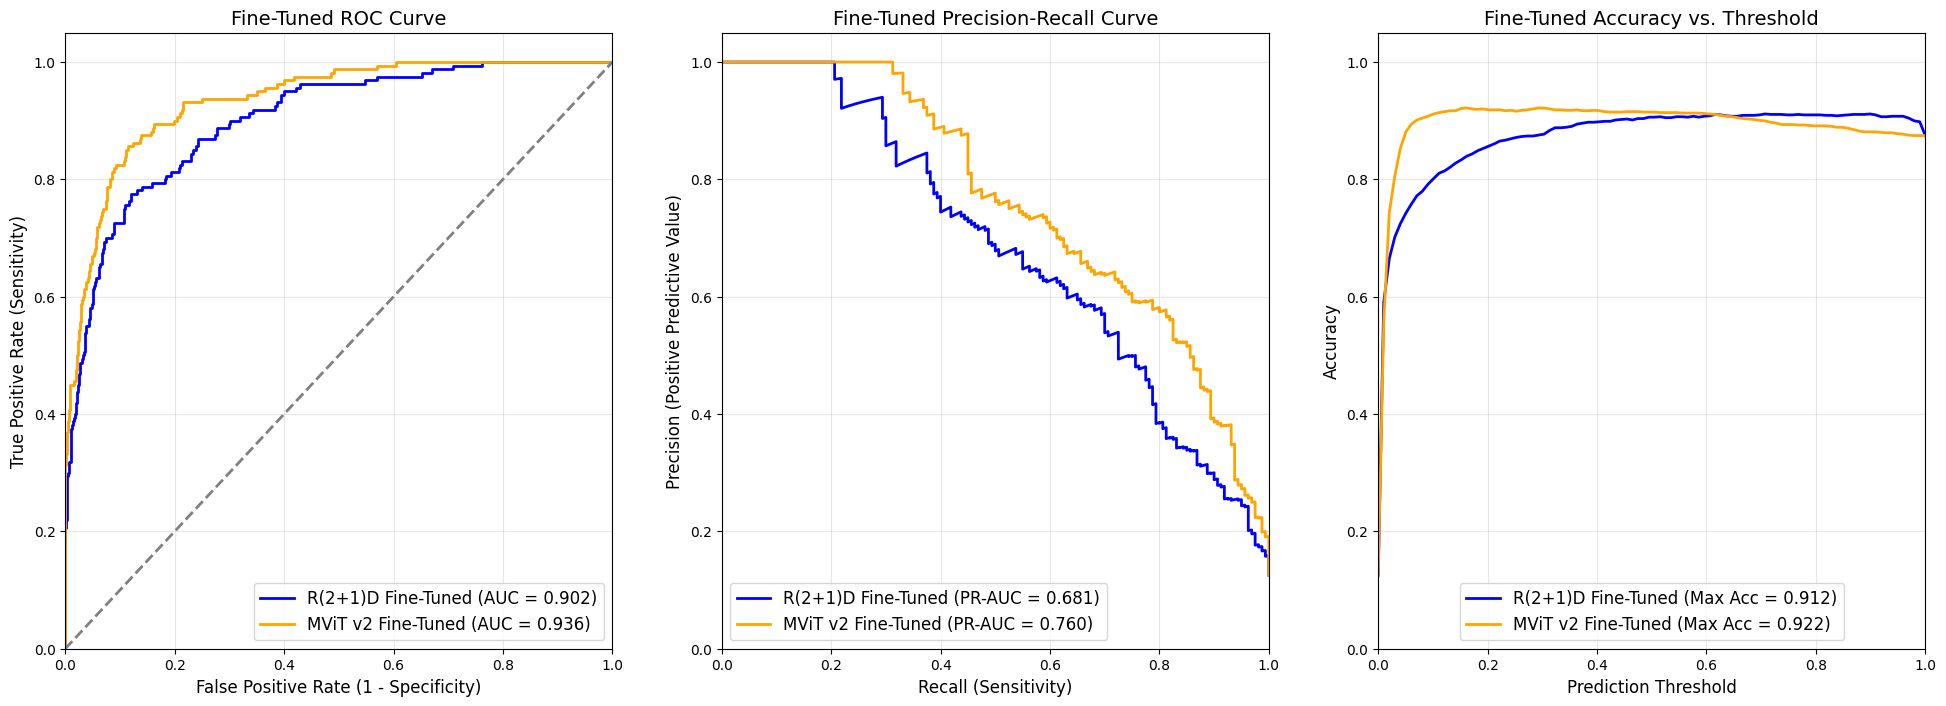

In [7]:
if plot_data:
    print("Generating combined ROC, PR, and Accuracy Curves...")
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    colors = {"r2plus1d": "blue", "mvit": "orange"}
    labels = {"r2plus1d": "R(2+1)D Fine-Tuned", "mvit": "MViT v2 Fine-Tuned"}
    
    # --- ROC Curve Subplot ---
    for name, data in plot_data.items():
        axes[0].plot(data["fpr"], data["tpr"], color=colors.get(name, "green"), lw=2, 
                        label=f'{labels.get(name, name)} (AUC = {data["roc_auc"]:.3f})')
    
    axes[0].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    axes[0].set_title('Fine-Tuned ROC Curve', fontsize=14)
    axes[0].legend(loc="lower right", fontsize=12)
    axes[0].grid(alpha=0.3)
    
    # --- Precision-Recall Subplot ---
    for name, data in plot_data.items():
        axes[1].plot(data["recall"], data["precision"], color=colors.get(name, "green"), lw=2, 
                        label=f'{labels.get(name, name)} (PR-AUC = {data["pr_auc"]:.3f})')
    
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
    axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
    axes[1].set_title('Fine-Tuned Precision-Recall Curve', fontsize=14)
    axes[1].legend(loc="lower left", fontsize=12)
    axes[1].grid(alpha=0.3)
    
    # --- Accuracy vs. Threshold Subplot ---
    for name, data in plot_data.items():
        axes[2].plot(data["thresholds"], data["accuracies"], color=colors.get(name, "green"), lw=2, 
                        label=f'{labels.get(name, name)} (Max Acc = {max(data["accuracies"]):.3f})')
    
    axes[2].set_xlim([0.0, 1.0])
    axes[2].set_ylim([0.0, 1.05])
    axes[2].set_xlabel('Prediction Threshold', fontsize=12)
    axes[2].set_ylabel('Accuracy', fontsize=12)
    axes[2].set_title('Fine-Tuned Accuracy vs. Threshold', fontsize=14)
    axes[2].legend(loc="lower center", fontsize=12)
    axes[2].grid(alpha=0.3)
    
    # Save output
    output_img_path = ROOT / "outputs" / "finetuned_roc_pr_acc_curves.png"
    output_img_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_img_path, dpi=300, bbox_inches='tight')
    print(f"Saved overlay graph to: {output_img_path}")

In [ ]:
print("\n--- The Verdict ---")
preds_dir = ROOT / "outputs" / "predictions"
cnn_csv = preds_dir / "r2plus1d_test_predictions.csv"
mvit_csv = preds_dir / "mvit_test_predictions.csv"

if cnn_csv.exists() and mvit_csv.exists():
    df_cnn = pd.read_csv(cnn_csv)
    df_mvit = pd.read_csv(mvit_csv)
    
    y_true = df_mvit["Label"].values # Labels are identical for both models
    probs_mvit = df_mvit["Probability"].values
    probs_cnn = df_cnn["Probability"].values
    
    mean_diff, ci_lower, ci_upper = paired_bootstrap_auc(y_true, probs_mvit, probs_cnn)
    print(f"Mean Difference (MVIT - CNN): {mean_diff:.4f}")
    print(f"95% CI of Difference: [{ci_lower:.4f}, {ci_upper:.4f}]")

    if ci_lower > 0:
        print("Scenario A: The 'Transformer Triumph'. MVIT significantly outperformed the CNN.")
    elif ci_upper < 0:
        print("Scenario B: The 'CNN Stronghold'. R(2+1)D significantly outperformed the MVIT.")
    else:
        print("Statistical Tie: 0 is within the 95% CI of the difference. Neither architecture strictly dominated.")
else:
    print("Could not find prediction CSVs to run the paired bootstrap test.")


--- The Verdict ---
Mean Difference (MVIT - CNN): 0.0343
95% CI of Difference: [0.0132, 0.0567]
Scenario A: The 'Transformer Triumph'. MVIT significantly outperformed the CNN.
